<a href="https://colab.research.google.com/github/Francisakinrinade/3MTT_DeepTechReady/blob/main/6_sentiment__analysis_with__neural__networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis with Neural Networks

One of the common uses for binary classification in machine learning is analyzing text for sentiment — specifically, assigning a text string a score from 0 to 1, where 0 represents negative sentiment and 1 represents positive sentiment. A restaurant review such as "Best meal I've ever had and awesome service, too!" might score 0.9 or higher, while a statement such as "Long lines and poor customer service" would score closer to 0. Marketing departments sometimes use sentiment-anlysis models to monitor social-media services for feedback so they can respond quickly if, for example, comments regarding their company suddenly turn negative.

To train a neural network to perform sentiment analysis, you need a dataset containing text strings labeled with 0s (for negative sentiment) and 1s (for positive sentiment). Several such datasets are available in the public domain. We will use one containing 50,000 movie reviews, each labeled with a 0 or 1. Once the network is trained, scoring a text string for sentiment is a simple matter of passing it to the network and asking for the probability that the predicted label is 1. A probability of 80% means the sentiment score is 0.8 and that the text is very positive.

## Load and prepare the data

The first step is to load the dataset and prepare it for use in machine learning. There's no need to tokenize the text since we'll use a [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/core_preprocessing_layers/text_vectorization/) layer to do the tokenizing.

In [ ]:
# import pandas as pd

# df = pd.read_csv('reviews.csv', encoding="ISO-8859-1")
# df = df.sample(frac=1, random_state=0)
# df.head()

,Text,Sentiment
11841,Al Pacino was once an actor capable of making ...,0
19602,After Chaplin made one of his best films: Doug...,0
45519,This movie is sort of a Carrie meets Heavy Met...,1
25747,I have fond memories of watching this visually...,1
42642,"In the '70s, Charlton Heston starred in sci-fi...",1


In [ ]:
# Import Data Files from Google Drive

import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw

url = "https://drive.google.com/file/d/1dmYtXJSCYZDRae8XFkKfPuBbCsbrJMuT/view?usp=drive_link"
gdd = read_gd(url)

df = pd.read_csv(gdd, encoding="ISO-8859-1")

Remove duplicate rows and check for balance.

In [ ]:
df = df.drop_duplicates()
df.groupby('Sentiment').describe()

Text                                                            \
           count unique                                                top   
Sentiment                                                                    
0          24697  24697  This is one of the dumbest films, I've ever se...   
1          24884  24884  Working-class romantic drama from director Mar...   

                
          freq  
Sentiment       
0            1  
1            1

## Train a neural network

Create a neural network containing a `TextVectorization` layer for vectorizing text, an [Embedding](https://keras.io/api/layers/core_layers/embedding/) layer for converting sequences into arrays of word vectors, and a [Dense](https://keras.io/api/layers/core_layers/dense/) layer for classifying arrays of word vectors.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TextVectorization, InputLayer
from tensorflow.keras.layers import Dense, Flatten, Embedding, GlobalAveragePooling1D
import tensorflow as tf

# Network parameters
max_words = 20000
max_length = 500

# Build the neural network model
print("\nBuilding neural network...")
model = Sequential([
    InputLayer(input_shape=(1,), dtype=tf.string),
    TextVectorization(max_tokens=max_words, output_sequence_length=max_length),
    Embedding(max_words + 1, 32, input_length=max_length),  # +1 for reserved index 0
    GlobalAveragePooling1D(),  # stable than Flatten for variable-length sequences
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


Building neural network...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Display model architecture
print("\nModel Architecture:")
model.summary()


Model Architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_7            │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 500, 32)        │       640,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,385 (2.46 MB)

 Trainable params: 644,385 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

Extract text from the "Text" column and labels from the "Sentiment" column.

In [ ]:
# Extract features and labels
x = df['Text']
y = df['Sentiment']

print(f"\nTraining data shape: {len(x)} samples")
print(f"Label distribution: {y.value_counts().to_dict()}")


Training data shape: 49581 samples
Label distribution: {1: 24884, 0: 24697}


Fit the `TextVectorization` layer to the text, and then train the network and capture the training history returned by `fit`.

In [ ]:
# model.build(input_shape=(None, 1))

print("\nAdapting TextVectorization layer...")
text_vectorization_layer = model.layers[0]
text_vectorization_layer.adapt(x)


Adapting TextVectorization layer...


In [ ]:
# Convert to tensors
x_tensor = tf.constant(x.values, dtype=tf.string)
y_tensor = tf.constant(y.values, dtype=tf.float32)

In [ ]:
print("\nStarting training...")
# Train the model
hist = model.fit(
    x_tensor,
    y_tensor,
    validation_split=0.2,
    epochs=5,
    batch_size=250,
    verbose=1
)



Starting training...
Epoch 1/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - accuracy: 0.6227 - loss: 0.6646 - val_accuracy: 0.1065 - val_loss: 0.8906
Epoch 2/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.7377 - loss: 0.5279 - val_accuracy: 0.5234 - val_loss: 0.7825
Epoch 3/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8479 - loss: 0.3569 - val_accuracy: 0.8436 - val_loss: 0.3909
Epoch 4/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.8821 - loss: 0.2933 - val_accuracy: 0.7547 - val_loss: 0.5566
Epoch 5/5
159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.8916 - loss: 0.2640 - val_accuracy: 0.9193 - val_loss: 0.2393


See how the training and validation accuracy evolved and make sure the network was trained for a sufficient number of epochs.

[]

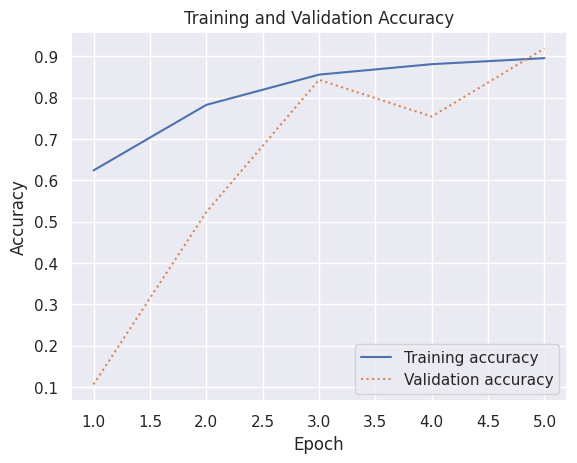

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set()

acc = hist.history['accuracy']
val = hist.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, '-', label='Training accuracy')
plt.plot(epochs, val, ':', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.plot()

## Use the model to analyze text

Let's score a couple of reviews by passing them to the model's `predict` method.

In [ ]:
# Test the model with sample predictions from the dataset
print(f"\n=== Sample Predictions ===")
# Use some actual reviews from the dataset for testing
test_texts = [
    "This movie is absolutely fantastic! Great acting and amazing story.",
    "Terrible film, waste of time and money. Very disappointed.",
    "One of the best movies I've ever seen, highly recommend!",
    "Boring and predictable plot, poor acting throughout."
]

test_tensor = tf.constant(test_texts, dtype=tf.string)
predictions = model.predict(test_tensor)

for text, pred in zip(test_texts, predictions):
    sentiment = "Positive" if pred[0] > 0.5 else "Negative"
    confidence = pred[0] if pred[0] > 0.5 else 1 - pred[0]
    print(f"Text: '{text}'")
    print(f"Prediction: {sentiment} (confidence: {confidence:.3f})")
    print("-" * 50)


=== Sample Predictions ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Text: 'This movie is absolutely fantastic! Great acting and amazing story.'
Prediction: Positive (confidence: 0.934)
--------------------------------------------------
Text: 'Terrible film, waste of time and money. Very disappointed.'
Prediction: Negative (confidence: 0.585)
--------------------------------------------------
Text: 'One of the best movies I've ever seen, highly recommend!'
Prediction: Positive (confidence: 0.936)
--------------------------------------------------
Text: 'Boring and predictable plot, poor acting throughout.'
Prediction: Negative (confidence: 0.622)
--------------------------------------------------


Do the sentiment scores output by the model seem accurate?